ESERCIZIO

Immagina di analizzare un immagine media (es. radiografica dei vasi sanguigni) dove i vasi appaiono come linee bianche su sfondo nero, ma sono molto frammentati a causa del rumore del sensore

Crea un'immagine nera 200x200 con numpy e disegna due linee bianche spezzete che dovrebbero essere unite.

Applica l'operazione di closing con un kernel rettangolare 7x7 per unire i segmenti

Sfida: applica il gradiente morfologico (dilatazione - erosione) sull'immagine risultante per estrarre solo il contorno dei vasi uniti.



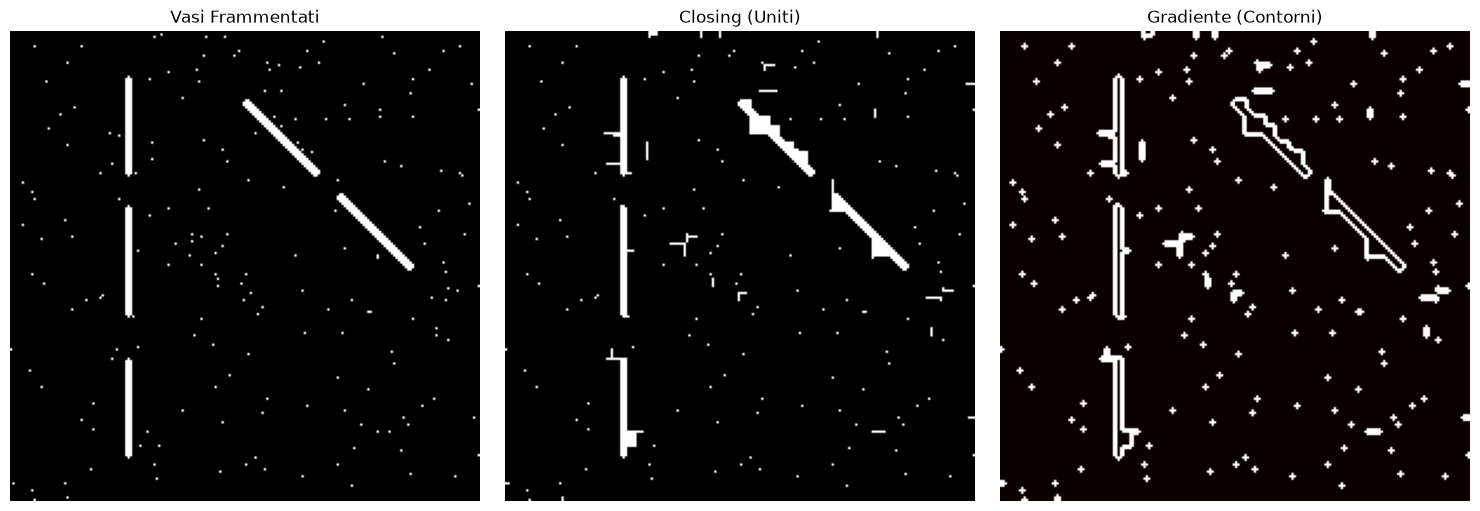

Forma del tensore Keras: torch.Size([200, 200])


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Configurazione Keras 3 con backend PyTorch
os.environ["KERAS_BACKEND"] = "torch"
import keras

def medical_imaging_morphology_lab():
    # 1. CREAZIONE DELL'IMMAGINE SINTETICA (Angiografia frammentata)
    # Creiamo un fondo nero 200x200
    img = np.zeros((200, 200), dtype=np.uint8)
    
    # Disegniamo due vasi sanguigni frammentati (linee spezzate)
    # Vaso 1: Verticale con interruzioni
    cv2.line(img, (50, 20), (50, 60), 255, 2)
    cv2.line(img, (50, 75), (50, 120), 255, 2)
    cv2.line(img, (50, 140), (50, 180), 255, 2)
    
    # Vaso 2: Diagonale con interruzioni
    cv2.line(img, (100, 30), (130, 60), 255, 2)
    cv2.line(img, (140, 70), (170, 100), 255, 2)
    
    # Aggiungiamo un po' di rumore "sale" (pixel bianchi isolati)
    noise = np.random.randint(0, 2, (200, 200), dtype=np.uint8) * 255
    noise = cv2.bitwise_and(noise, noise, mask=(np.random.rand(200, 200) > 0.99).astype(np.uint8))
    fragmented_vessels = cv2.bitwise_or(img, noise)

    # 2. DEFINIZIONE DELL'ELEMENTO STRUTTURANTE (Challenge: Rettangolare 7x7)
    # Il kernel rettangolare è più aggressivo nel connettere segmenti vicini.
    kernel_join = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))

    # 3. CLOSING (Unione dei segmenti)
    # Teoria: La dilatazione espande i segmenti finché non si toccano, 
    # l'erosione successiva riporta lo spessore alla dimensione quasi originale.
    united_vessels = cv2.morphologyEx(fragmented_vessels, cv2.MORPH_CLOSE, kernel_join)

    # 4. GRADIENTE MORFOLOGICO (Estrazione contorni)
    # Teoria: (Dilatazione - Erosione). Sottrae l'immagine "ristretta" da quella "espansa".
    # Il risultato sono solo i pixel di confine (il perimetro dei vasi).
    gradient_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    vessel_contours = cv2.morphologyEx(united_vessels, cv2.MORPH_GRADIENT, gradient_kernel)

    # 5. INTEGRAZIONE KERAS 3
    # Trasformiamo il risultato finale in un tensore per un'eventuale segmentazione AI
    contour_tensor = keras.ops.convert_to_tensor(vessel_contours, dtype="float32") / 255.0

    # VISUALIZZAZIONE
    titles = ['Vasi Frammentati', 'Closing (Uniti)', 'Gradiente (Contorni)']
    images = [fragmented_vessels, united_vessels, vessel_contours]
    
    plt.figure(figsize=(15, 5))
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(images[i], cmap='hot' if i==2 else 'gray')
        plt.title(titles[i])
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

    print(f"Forma del tensore Keras: {contour_tensor.shape}")
    return contour_tensor

if __name__ == "__main__":
    medical_imaging_morphology_lab()